# Chapter 4: Long/Short Methodologies: Absolute and Relative

This chapter introduces the relative series methodology
1. Import libraries & path to save files
2. Build a dataframe of S&P 500 constituents
3. Download historical prices with yfinance library
4. Bullish/Bearish regime in absolute/relative series
5. Relative  & Utilities Function
6. Softbank in absolute JPY & relative to Nasdaq 100 in USD
7. GEMS Stocks relative to S&P 500
8. Sector Average
9. Cyclicals v. defensives
10. Cross-market comparison
11. Disney MCU rise and fall

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
%matplotlib inline
import matplotlib.pyplot as plt
import pathlib
import datetime 
from datetime import timedelta 

In [2]:
def path_folder(folder, home = False):
    if home == True:
        directory = pathlib.Path.home() /  folder
    else:
        directory = pathlib.Path.cwd() / folder
        
    if not directory.exists():
        directory.mkdir(parents=True, exist_ok=True)    
    return directory

folder ="data"
directory = path_folder(folder, home = False)
directory

WindowsPath('c:/Users/Laurent/Dropbox/Python/Algorithmic-Short-Selling-with-Python-2nd-Edition/data')

### 2. Build a dataframe of S&P 500 constituents

1. Pandas read_html is an efficient way to convert tables from the internet into dataframe. 
2. Webpages often contain multiple tables, so make sure you index the correct table. Here we reference the first table on the page [0]
3. Next, we rename columns. Different webpages have different names for the same fields: symbol v. ticker, GICS sector v. sector etc. We make a habit of harmonising names to facilitate processing
4. We will be downloading historical prices from Yahoo. So, we need to convert tickers into a format compatible with the yfinance library: .str.replace('.', '-', regex =False)
5. We sort tickers by sector and ticker in ascending order
Tip: Tables and webpages get updated regularly so make sure to check the shape of the df.

In [3]:
df_SP500 = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
df_SP500 = df_SP500.rename(columns={'Symbol':'ticker', 'Security': 'name', 'GICS Sector':'sector','GICS Sub-Industry':'sub-industry'})
df_SP500['ticker'] = df_SP500['ticker'].str.replace('.', '-', regex =False)
df_SP500 = df_SP500.sort_values(by = ['sector','name']).set_index('ticker')

bm_ticker = '^GSPC'
tickers_list = [bm_ticker] + list(df_SP500.index)[:]
df_SP500.groupby('sector').count()

,name,sub-industry,Headquarters Location,Date added,CIK,Founded
sector,,,,,,
Communication Services,22,22,22,22,22,22
Consumer Discretionary,52,52,52,52,52,52
Consumer Staples,38,38,38,38,38,38
Energy,22,22,22,22,22,22
Financials,71,71,71,71,71,71
Health Care,63,63,63,63,63,63
Industrials,78,78,78,78,78,78
Information Technology,67,67,67,67,67,67
Materials,28,28,28,28,28,28


In [4]:
### Save df and read: NO need to publish in the book version
df_SP500.to_csv(directory /'df_SP500_sectors.csv')
df_SP500 = pd.read_csv(directory /'df_SP500_sectors.csv', index_col= [0],parse_dates= True).round(2)
df_SP500.shape

(503, 7)

### 3. Download historical prices with yfinance library

1.	Variables:
    1.	tickers_list: make sure all tickers are compatible with the yfinance library 
    2.	batch_size = 20, we process data in batches
    3.	start, end: self-explanatory
    4.	show_batch = True, shows tickers asthey are downloaded
2.	Loop to download ['Close'] prices in batches
3.	Populate the df_abs by joining each batch 
4.	return px_df 
5.	Generate df_rel of relative prices by dividing the df_abs by the bnechmark ticker and rebase to the first benchmark value 
6.	Print the shape of the absolute and relative df


In [5]:
def batch_px_df(tickers_list,batch_size, start, end,show_batch = False):
    px_df = pd.DataFrame()
    loop_size = int(len(tickers_list) // batch_size) + 2
    for t in range(1,loop_size): # Batch download
        try:
            m = (t - 1) * batch_size
            n = t * batch_size
            batch_list = tickers_list[m:n]
            if show_batch:
                print(batch_list,m,n)
            batch_download = yf.download(tickers= batch_list,start= start, end = end, interval = "1d",
                                group_by = 'column',auto_adjust = True, prepost = True,  proxy = None)['Close']
            px_df = px_df.join(batch_download, how='outer')
        except:
            pass
    return px_df

In [6]:
batch_size = 25 ; start= '2001-01-01' ; end = None

df_abs = batch_px_df(tickers_list,batch_size, start, end,show_batch = False)
df_rel = round(df_abs.divide(df_abs[bm_ticker], axis=0).mul(df_abs[bm_ticker][0]),1)
df_abs.shape, df_rel.shape  

[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*****

((5923, 504), (5923, 504))

In [7]:
### Save df and read: NO need to publish in the book version
df_abs.to_csv(directory /'df_abs.csv')
df_rel.to_csv(directory /'df_rel.csv')

In [8]:
### Save df and read: NO need to publish in the book version
df_abs = pd.read_csv(directory /'df_abs.csv', index_col= [0],parse_dates= True)
df_rel = pd.read_csv(directory /'df_rel.csv', index_col= [0],parse_dates= True)
print(df_abs.shape, df_rel.shape)

(5923, 504) (5923, 504)


### 4. Bullish/Bearish regime in absolute/relative series

We use a classic one-year high/low as a proxy for the bullish/bearish regime. Stocks that have printed a 256 one-year high are deemed bullish and expected to remain strong. Conversely, stocks that have printed a one-year low are expected to exhibit continued weakness. 

1. Instantiate a bullbear df. Copying the benchmark price and calculate cumulative returns
2. generate 2 dataframes from absolute and relative price series:
    1. np.where price hits a 256 day high, assign 1 for bullish
    2. np.where price hits a 256 day low, assign -1 for bearish
    3. else assign NaN
    4. forward fillna to propagate bullish or bearish regime
3. Lateral count of stocks in bullish or bearish territory. Calculate average lateral bullishness/bearishness for both absolute and relative series
4. Plot benchmark and lateral counts for the absolute, reative abs & rel, average absolute and relative

Absolute series are highly correlated to the benchmark. It is not uncommon to have close to 100% of the consituents be in either bullish or bearish territory. However, with relative series, roughly 40% to 60% of the constituents will be in either bullish or bearish territory at any point in time. This means there are more issues to shop from and bild a portfolio


In [9]:
window = 252 ;bullbear = pd.DataFrame()
bullbear['benchmark'] = df_abs[bm_ticker].copy()
bullbear['bm_returns'] = np.exp(np.log(bullbear/bullbear.shift()).cumsum()) - 1

bo_rel = pd.DataFrame(data = np.where(df_rel >= df_rel.rolling(window).max(),1,
                                np.where(df_rel <= df_rel.rolling(window).min(),-1,np.nan)), 
                      index= df_rel.index,columns= df_rel.columns).fillna(method='ffill')
bo_abs = pd.DataFrame(data= np.where(df_abs >= df_abs.rolling(window).max(),1,
                                     np.where(df_abs<=df_abs.rolling(window).min(),-1,np.nan)), 
                      index= df_abs.index,columns= df_abs.columns).fillna(method='ffill')

bo_abs_count = bo_abs.count(axis=1) 
bo_rel_count = bo_rel.count(axis=1) 
bullbear['bulls_absolute'] = bo_abs[bo_abs > 0].count(axis=1).div(bo_abs_count,fill_value=0) * 100
bullbear['bears_absolute'] = bo_abs[bo_abs < 0].count(axis=1).div(bo_abs_count,fill_value=0) * 100 
bullbear['bulls_relative'] = bo_rel[bo_rel > 0].count(axis=1).div(bo_rel_count,fill_value=0) * 100  
bullbear['bears_relative'] = bo_rel[bo_rel < 0].count(axis=1).div(bo_rel_count,fill_value=0) * 100  
bullbear['bullbear_absolute_avg'] = bo_abs.mean(axis=1) 
bullbear['bullbear_relative_avg'] = bo_rel.mean(axis=1) 
bullbear.tail()

,benchmark,bm_returns,bulls_absolute,bears_absolute,bulls_relative,bears_relative,bullbear_absolute_avg,bullbear_relative_avg
Date,,,,,,,,
2024-07-15,5631.220215,3.388180,75.951904,24.048096,30.8,69.2,0.519038,-0.384
2024-07-16,5667.200195,3.416218,76.352705,23.647295,30.8,69.2,0.527054,-0.384
2024-07-17,5588.270020,3.354711,76.953908,23.046092,30.8,69.2,0.539078,-0.384
2024-07-18,5544.589844,3.320673,76.953908,23.046092,30.8,69.2,0.539078,-0.384
2024-07-19,5505.000000,3.289822,76.953908,23.046092,31.4,68.6,0.539078,-0.372


(5923, 504) (5923, 504) (5923, 8)


<Figure size 640x480 with 0 Axes>

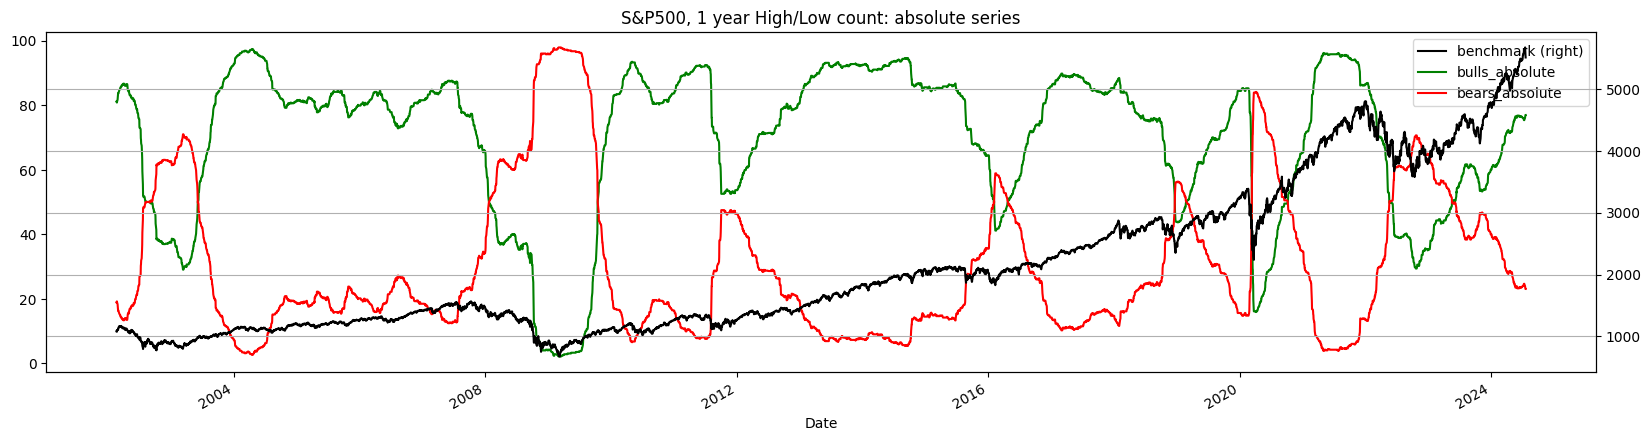

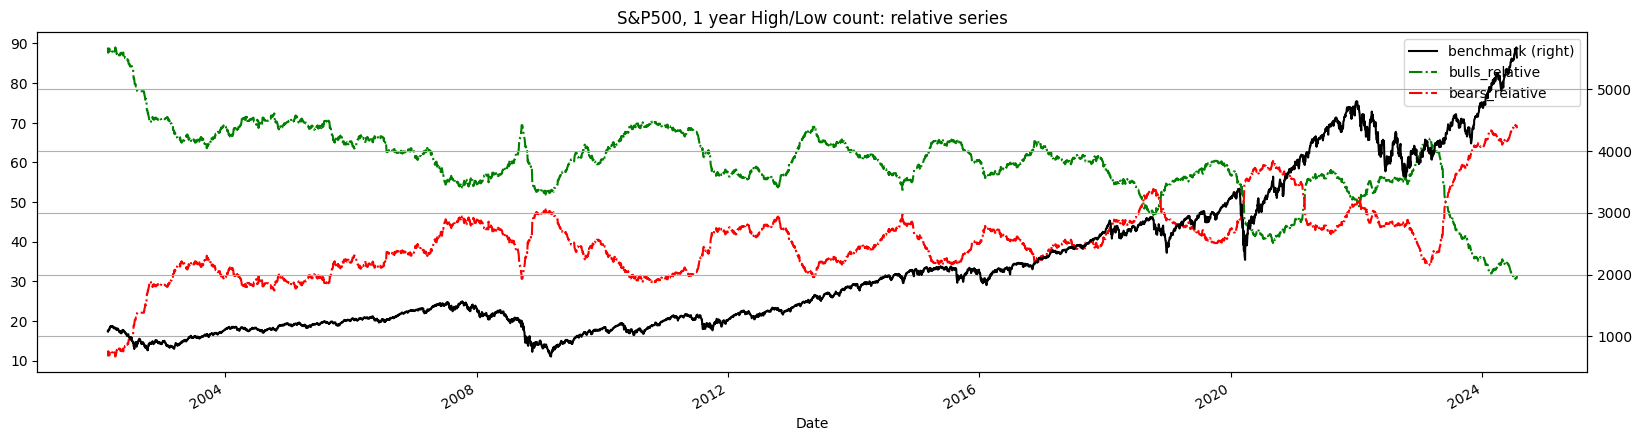

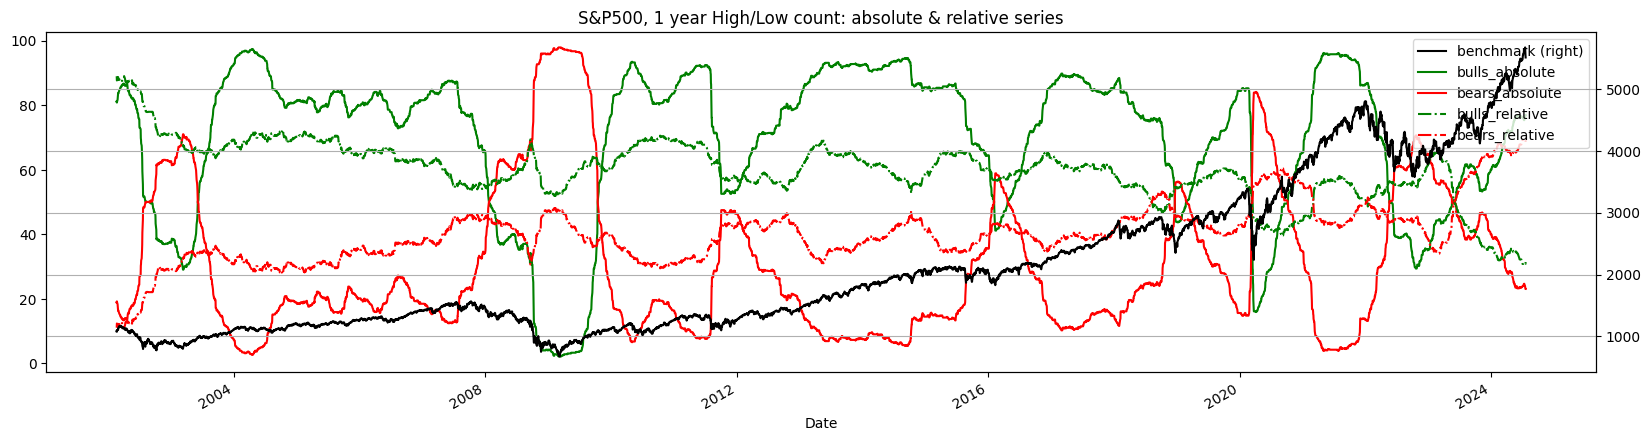

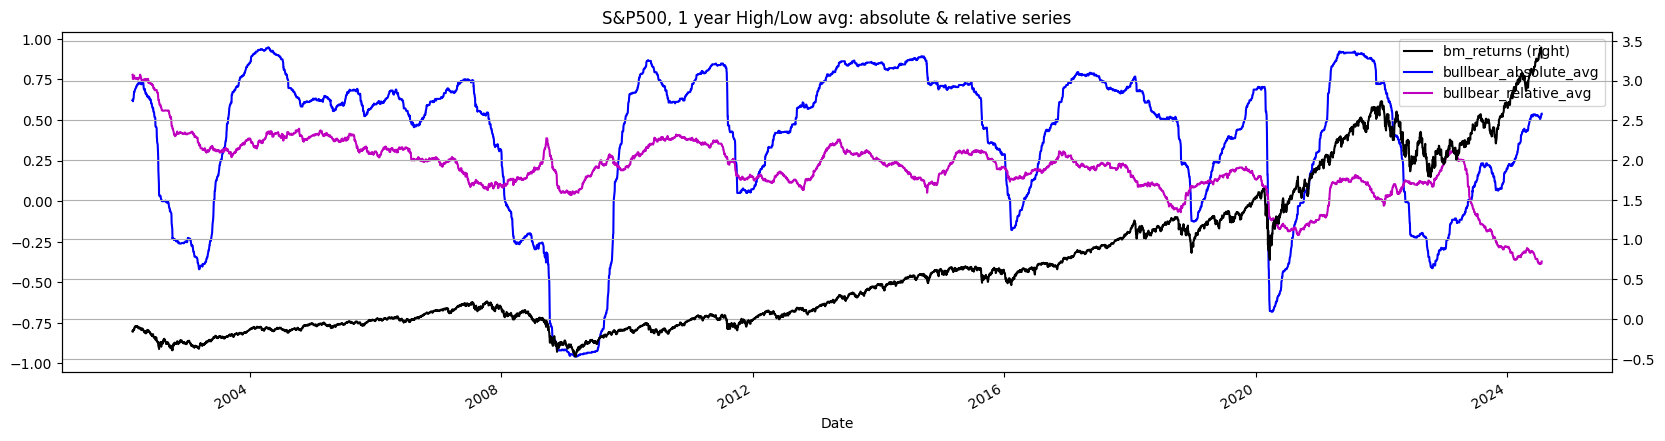

In [10]:
plt.tight_layout()

fig1 = bullbear[280:][['benchmark','bulls_absolute', 'bears_absolute']].plot(figsize=(20,5),
                style=['k','g', 'r'],grid=True,secondary_y=['benchmark'],
                title = 'S&P500, 1 year High/Low count: absolute series').get_figure()
fig1.savefig(directory/'Ch04_S&P500_1Y_regime_absolute_series.png')

fig2 = bullbear[280:][['benchmark','bulls_relative', 'bears_relative']].plot(figsize=(20,5),
                style=['k','g-.', 'r-.'],grid=True,secondary_y=['benchmark'],
                title = 'S&P500, 1 year High/Low count: relative series').get_figure()
fig2.savefig(directory/'Ch04_S&P500_1Y_regime_relative_series.png')

fig3 = bullbear[280:][['benchmark','bulls_absolute', 'bears_absolute', 'bulls_relative', 'bears_relative']].plot(figsize=(20,5),
                style=['k','g', 'r','g-.', 'r-.'],grid=True,secondary_y=['benchmark'],
                title = 'S&P500, 1 year High/Low count: absolute & relative series').get_figure()
fig3.savefig(directory/'Ch04_S&P500_1Y_regime_absolute_relative_series.png')

fig4 = bullbear[280:][['bm_returns','bullbear_absolute_avg','bullbear_relative_avg']].plot(figsize=(20,5),
                style=['k', 'b', 'm'],grid=True,secondary_y=['bm_returns'],
                title = 'S&P500, 1 year High/Low avg: absolute & relative series').get_figure()
fig4.savefig(directory/'Ch04_S&P500_1Y_regime_absolute_relative_averages.png')

### Save df and read: NO need to publish in the book version
bullbear.to_csv(directory /'bullbear.csv')
bo_abs.to_csv(directory /'bo_abs.csv')
bo_rel.to_csv(directory /'bo_rel.csv')
print(pd.read_csv(directory /'bo_abs.csv', index_col= [0],parse_dates= True).shape,
      pd.read_csv(directory /'bo_rel.csv', index_col= [0],parse_dates= True).shape,
      pd.read_csv(directory /'bullbear.csv', index_col= [0],parse_dates= True).shape)


### 5. Relative  & Utilities Function

1. rel_fx(df,_o,_h,_l,_c,bm_df,bm,ccy_df,ccy,start,end,rebase=True,mult=1) is a 2 step-process:
    1. Convert to benchmark currency
    2. Divide by the benchmark: 
        1. If you want to rebase to the beginning of the series. This works best when the start of the series is a fixed date. 
        2. If you use a moving window such as a roling 1Y, flaag False. Multiply by the constant mult to generate bigger numbers    

2. dict_swap(dct): this dictionary comprehension swaps keys and values
3. df_from_dict(batch_size,dct,start,end): this function downloads historical prices from dictionary keys,
 and swaps column names with values
4. rohlc(df,relative = False): this verbose function instantiates _o,_h,_l,_c

In [11]:
def rel_fx(df,_o,_h,_l,_c, bm_df, bm, ccy_df, ccy, start, end,rebase = True, mult = 1):
    df[ccy] = ccy_df.loc[start:end,ccy].copy().fillna(method = 'ffill')
    df[bm] = bm_df.loc[start:end,bm].copy().fillna(method = 'ffill')
    for i in [_o,_h,_l,_c]:
        df[f'r{i}'] = df[i].div(df[ccy])
        if rebase == True:
            df[f'r{i}'] = df[f'r{i}'].div(df[bm]).mul(df[df[bm].notna()][bm][0])
        else:
            df[f'r{i}'] = df[f'r{i}'].div(df[bm]) * mult
    return df

def dict_swap(dct):
    dict_swap = {value:key for key,value in dct.items()}
    return dict_swap

def df_from_dict(batch_size,dct,start,end):
    tickers_list = list(dct.keys())
    df = batch_px_df(tickers_list,batch_size, start, end,show_batch = False)
    df = df.rename(columns = dct)
    df = df.fillna(method = 'ffill')
    return df

def rohlc(df,relative = False):
    if relative==True:
        rel = 'r'
    else:
        rel= ''      
    if 'Open' in df.columns:
       _o,_h,_l,_c = f'{rel}Open',f'{rel}High',f'{rel}Low',f'{rel}Close'      
    elif 'open' in df.columns:
        _o,_h,_l,_c = f'{rel}open',f'{rel}high',f'{rel}low',f'{rel}close'
    else:
        _o=_h=_l=_c= np.nan
    return _o,_h,_l,_c

### 6. Softbank in absolute JPY & relative to Nasdaq 100 in USD

1. We create dictionaries of benchmarks and currencies. We download historical prices. We add 'absolute' and 'local' with 1 values. The bm_df and ccy_df will be re-purposed later
2. We download historical prices for Softbank, instantiate _o,_h,_l,_c, calculate relative prices and plot both absolute in local currency and relative is USD

In [12]:
batch_size = 25 ; start = '2018-12-30' ; end = None ;
dict_bm = {'^GSPC': 'SP500', '^DJI': 'DOW30', '^IXIC': 'Nasdaq100', '^NYA': 'NYSE ', '^XAX': 'Nyse_Amex', '^RUT': 'Russell2000',
           '^VIX': 'VIX', '^BUK100P': 'CBOEUK100', '^FTSE': 'FTSE100', '^GDAXI': 'DAX', '^FCHI': 'CAC40', '^STOXX50E': 'EuroStocks50', 
           '^N100': 'Euronext100', '^BFX': 'BEL20', 'IMOEX.ME': 'MOEX_Russia', '^N225': 'Nikkei225', '^HSI': 'HangSeng', 
           '000001.SS': 'SSE', '399001.SZ': 'Shenzhen', '^STI': 'STI', '^AXJO': 'ASX200', '^AORD': 'All_Ordinaries', '^BSESN': 'Sensex', 
           '^JKSE': 'Jakarta','^KLSE': 'FTSE_KLCI', '^JKSE': 'Jakarta', '^KLSE': 'FTSE_KLCI', '^NZ50': 'NZX50', '^KS11': 'Kospi', 
           '^TWII': 'TSEC', '^GSPTSE': 'TSX', '^BVSP': 'Bovespa',  '^MXX': 'IPC_Mexico', '^MERV': 'Merval', '^TA125.TA': 'TA125',
           '^IRX': '3M_US_Yield', '^FVX': '5Y_US_Yield', '^TNX': '10Y_US_Yield', '^TYX': '30Y_US_Yield'}
bm_df = df_from_dict(batch_size,dict_bm,start,end)
bm_df['absolute'] = 1

dict_ccy = {'EURUSD=X': 'EURUSD', 'JPY=X': 'USDJPY', 'GBPUSD=X': 'GBPUSD', 'AUDUSD=X': 'AUDUSD', 'NZDUSD=X': 'NZDUSD', 'USDCAD=X': 'USDCAD',
            'EURJPY=X': 'EURJPY', 'GBPJPY=X': 'GBPJPY', 'EURGBP=X': 'EURGBP', 'EURCAD=X': 'EURCAD', 'EURSEK=X': 'EURSEK', 'EURCHF=X': 'EURCHF',
             'EURHUF=X': 'EURHUF','CNY=X': 'USDCNY', 'HKD=X': 'USDHKD','SGD=X': 'USDSGD','INR=X': 'USDINR', 'KRW=X': 'USDKRW','TWD=X': 
            'USDTWD', 'MXN=X': 'USDMXN', 'PHP=X': 'USDPHP', 'IDR=X': 'USDIDR', 'THB=X': 'USDTHB', 'MYR=X': 'USDMYR', 'ZAR=X': 'USDZAR',
            'RUB=X': 'USDRUB', 'BRL=X': 'USDBRL'}
ccy_df = df_from_dict(batch_size,dict_ccy,start,end)
ccy_df['local'] = 1

bm = 'Nasdaq100' ; ccy = 'USDJPY' ; dgt = 2
ticker = '9984.T' # Softbank
df =  round(yf.download(tickers= ticker,start= start, end = end, interval = "1d",group_by = 'column',
                        auto_adjust = True, prepost = True),2)

_o,_h,_l,_c = rohlc(df,relative = False)
df = rel_fx(df,_o,_h,_l,_c, bm_df, bm, ccy_df, ccy, start, end,rebase = True, mult = 1)

[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  12 of 12 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


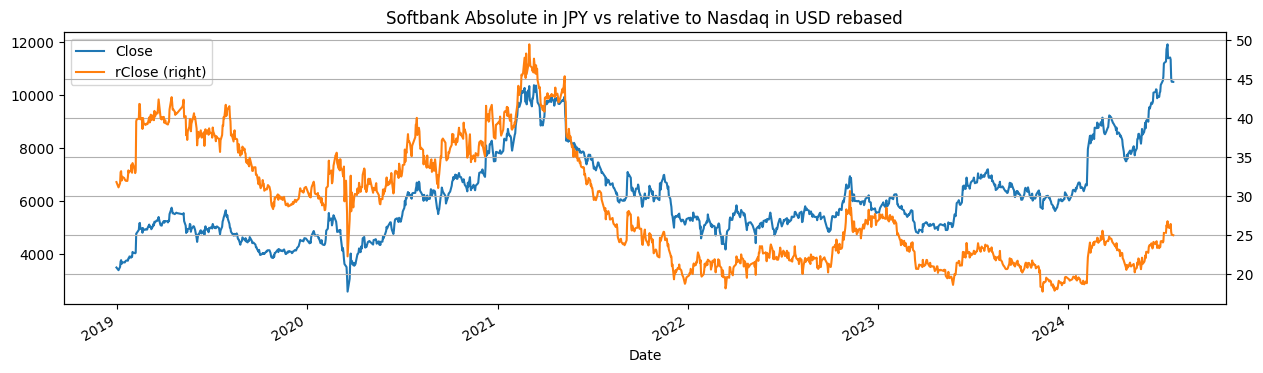

In [13]:
fig5 = df[['Close','rClose']].plot(figsize=(15,4),grid=True, secondary_y = ['rClose'],
            title= 'Softbank Absolute in JPY vs relative to Nasdaq in USD rebased' ).get_figure()
fig5.savefig(directory/'Ch04_Softbank Absolute in JPY vs relative to Nasdaq in USD rebased.png')

In [14]:
### Save df and read: NO need to publish in the book version
bm_df.to_csv(directory /'bm_df.csv')
ccy_df.to_csv(directory /'ccy_df.csv')
bm_df = pd.read_csv(directory /'bm_df.csv', index_col= [0],parse_dates= True)
ccy_df = pd.read_csv(directory /'ccy_df.csv', index_col= [0],parse_dates= True)
print(bm_df.shape,ccy_df.shape)

(1708, 38) (1451, 28)


### 7. GEMS Stocks relative to S&P 500

1. Tickers list
2. Download benchmark
3. Download close prices individually, divide by benchmark

In [15]:
tickers_list = ['GE','GM','GS']
gems = pd.DataFrame() 
start = '2020-03-31'
benchmark = yf.download(tickers= '^GSPC',start= start, end = None, 
                        interval = "1d",group_by = 'column',auto_adjust = True, 
                              prepost = True, proxy = None)['Close']
failed = [] ; rel_ticker_list = []
for ticker in tickers_list:
    try: #7 Download & process data
        gems[ticker] = yf.download(tickers= ticker,start= start, end = None, 
                        interval = "1d",group_by = 'column',auto_adjust = True, 
                              prepost = True, proxy = None)['Close']
        gems['rel_'+ticker] = gems[ticker].div(benchmark * gems[ticker][0]) * benchmark[0]
        rel_ticker_list.append('rel_'+ticker)
    except:
        failed.append(ticker)
gems = gems[tickers_list+rel_ticker_list]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


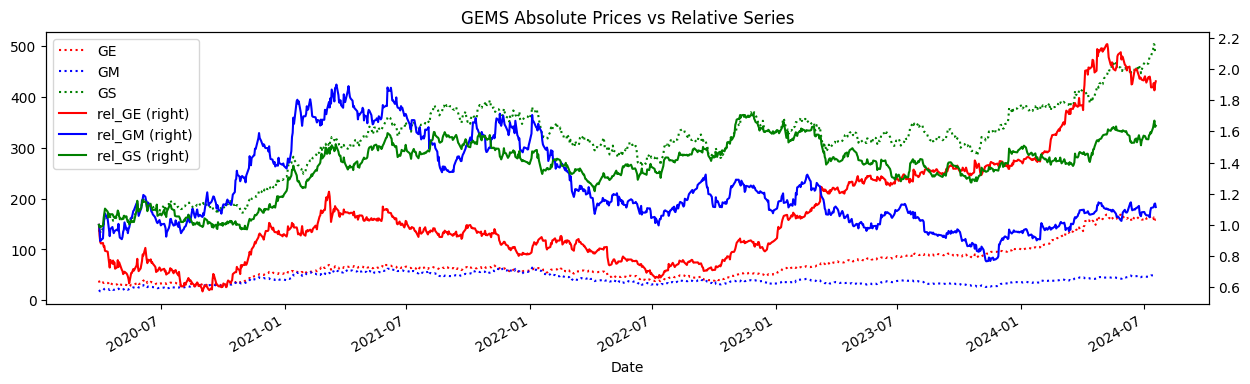

In [16]:
fig6 = gems.plot(figsize= (15,4),secondary_y= rel_ticker_list,style=['r:','b:','g:','r','b','g'], 
          title= 'GEMS Absolute Prices vs Relative Series' ).get_figure()
fig6.savefig(directory/'Ch04_GEMS Absolute Prices vs Relative Series.png')

### 8. Sector Average

We previously looked at the broad market number of bullish/bearish issues. Next, let’s drill down and look at what happens at the sector level.
We will join one specific column from the table dataframe we originally built from the internet with the historical regime df. We build a multi-index df, and then calculate the average by sector.

1. Concatenate one column (sector, industry group, industry or sub-industry) from the original table_df with the transposed historical_df. Rename index as the second name in the fields list
2. Reset index, then set index to create a hierarchical df with sector first and ticker second. Transpose
3. Groupby the first name in the fields list sector (level = 0), calculate mean along the X-axis. Drop NaN along the Y-axis. Rename the index as Date
2. Calculate sector_avg_abs & sector_avg_rel
3. Join sector_avg_abs & sector_avg_rel with the bullbear df. The suffic _abs & _rel are applied only where there are overlapping columns
4. Plot benchmark along with sectors in absolute and relative series

With the absolute series, everything is correlated. Cyclicals and defensives all go up and down along with the index. In bear markets, the only thing that goes up is correlation. Everything goes down synchronously. The game is to catch tops and bottoms as early as possible.
With the relative series, sectors come in and out of favour. This phenomenon is called sector rotation.


In [17]:
def agg_avg_df(table_df,historical_df, fields= ['sector','ticker']):
    multiIndex = pd.concat([table_df, historical_df.T], axis =1)
    multiIndex.index.names = [fields[1]]
    multiIndex = multiIndex.reset_index().set_index(fields).T
    agg_avg = multiIndex.groupby(level= 0, axis= 1).mean()
    agg_avg = agg_avg.dropna(axis= 0, how='all')
    agg_avg.index.names = ['date']
    return agg_avg

1. We calculate the sector average for the absolute and relative series
2. We rename columns with a dictionary comprehension
3. join returns an error when there duplicate columns. if the bullbear contains no column from the sector avg df, then join
4. We plot the benchmark, bullbear avg and sectors for both absolute and relative series

In [18]:
sector_avg_abs = agg_avg_df(table_df = df_SP500[['sector']],historical_df= bo_abs, fields= ['sector','ticker'])
sector_avg_abs = sector_avg_abs.rename(columns ={ s: f'{s}_abs' for s in sector_avg_abs.columns})
if sector_avg_abs.columns.any() not in bullbear.columns:
    bullbear = bullbear.join(sector_avg_abs)

sector_avg_rel = agg_avg_df(table_df = df_SP500[['sector']],historical_df= bo_rel, fields= ['sector','ticker'])
sector_avg_rel = sector_avg_rel.rename(columns ={ s: f'{s}_rel' for s in sector_avg_rel.columns})
if sector_avg_rel.columns.any() not in bullbear.columns:
    bullbear = bullbear.join(sector_avg_rel)

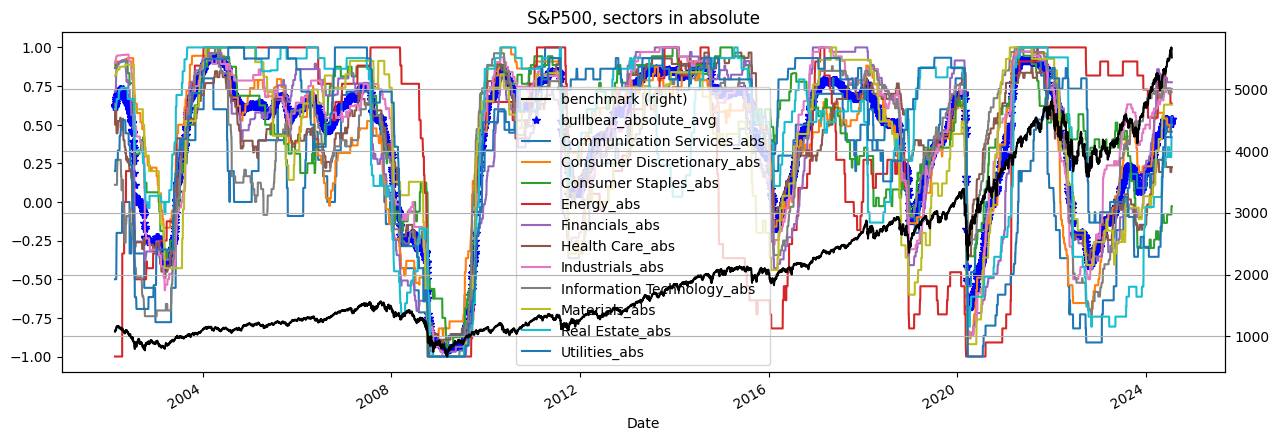

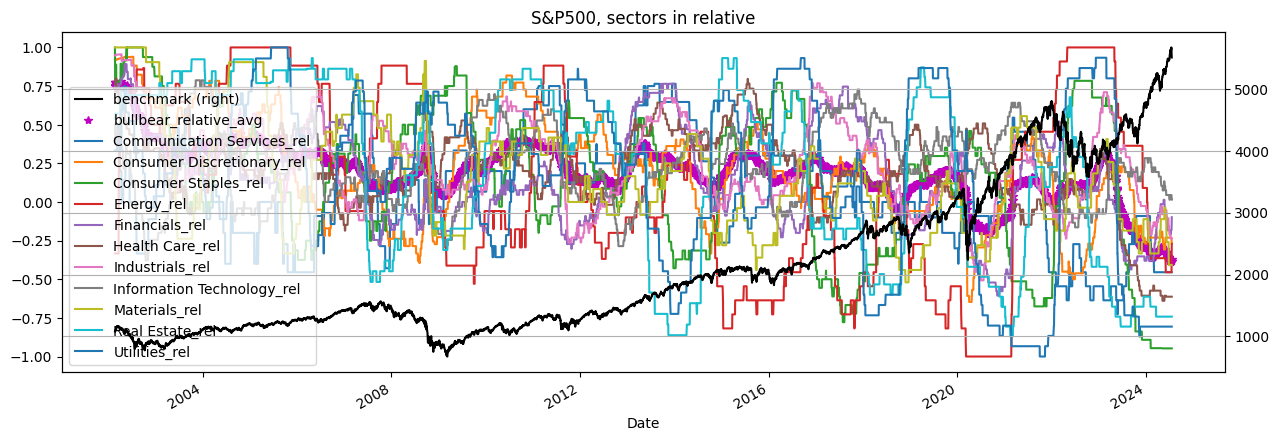

In [19]:
fig7 = bullbear[280:][['benchmark', 'bullbear_absolute_avg'] + list(sector_avg_abs.columns)].plot(figsize=(15,5),grid=True,
                    secondary_y=['benchmark'], style = ['k','b*'],title = 'S&P500, sectors in absolute').get_figure()
fig7.savefig(directory/'Ch04_S&P500, sectors in absolute.png')
fig8 =bullbear[280:][['benchmark','bullbear_relative_avg'] + list(sector_avg_rel.columns)].plot(figsize=(15,5),grid=True,
                    secondary_y=['benchmark'], style = ['k','m*'],title = 'S&P500, sectors in relative').get_figure()
fig8.savefig(directory/'Ch04_S&P500, sectors in relative.png')

### 9. Cyclicals v. defensives

1. Define defensives and cyclicals lists
2. We calculate the average of those two sectors. These are equal weight averages. 
3. We plot the defensives and cyclicals


In [20]:
defensives_list = ['Consumer Staples_rel', 'Consumer Staples_abs','Utilities_rel', 'Utilities_abs']
bullbear['defensives_rel'] = bullbear[ ['Consumer Staples_rel','Utilities_rel']].mean(axis=1)
bullbear['defensives_abs'] = bullbear[['Consumer Staples_abs','Utilities_abs']].mean(axis=1)
defensives_plot =['benchmark'] + defensives_list +['defensives_rel','defensives_abs'] 
                   
cyclicals_list = ['Consumer Discretionary_rel', 'Consumer Discretionary_abs',
                   'Information Technology_rel', 'Information Technology_abs',]
bullbear['cyclicals_abs'] = bullbear[[ 'Consumer Discretionary_abs', 'Information Technology_abs']].mean(axis=1)          
bullbear['cyclicals_rel'] = bullbear[[ 'Consumer Discretionary_rel', 'Information Technology_rel']].mean(axis=1)
cyclicals_plot = ['benchmark'] + cyclicals_list + ['cyclicals_rel','cyclicals_abs']

bullbear['rotation_rel'] = bullbear['cyclicals_rel'].sub(bullbear['defensives_rel'], fill_value =0)                   
bullbear['rotation_abs'] = bullbear['cyclicals_abs'].sub(bullbear['defensives_abs'], fill_value =0)     

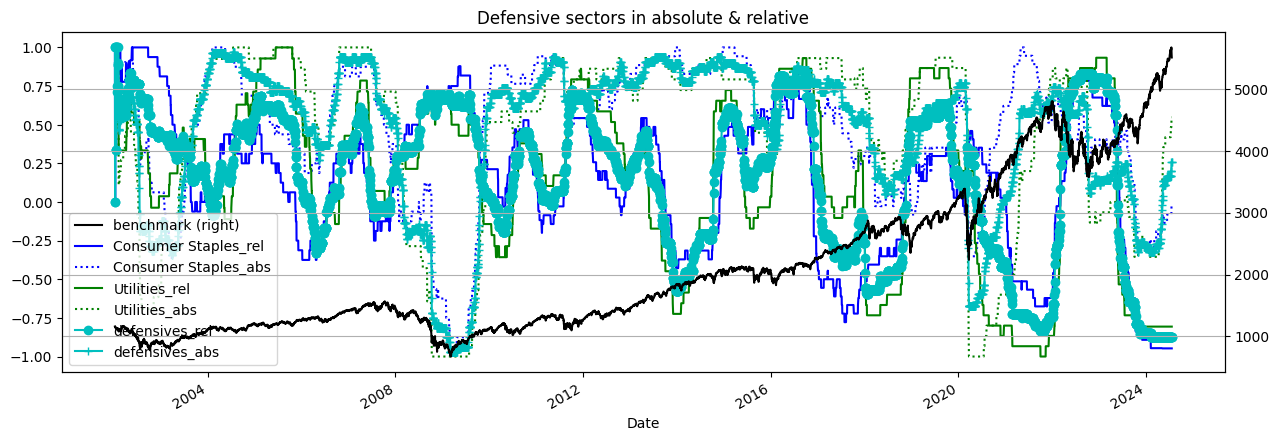

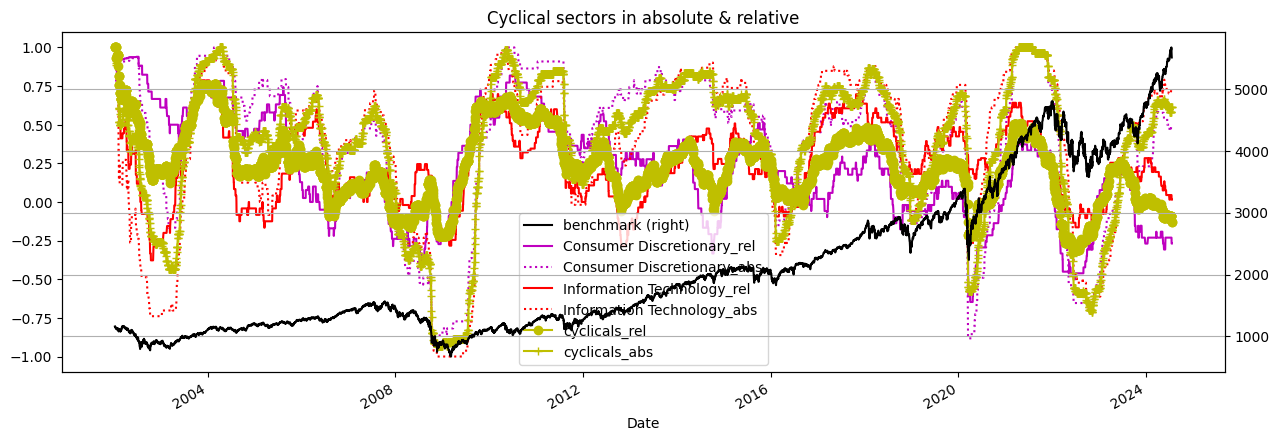

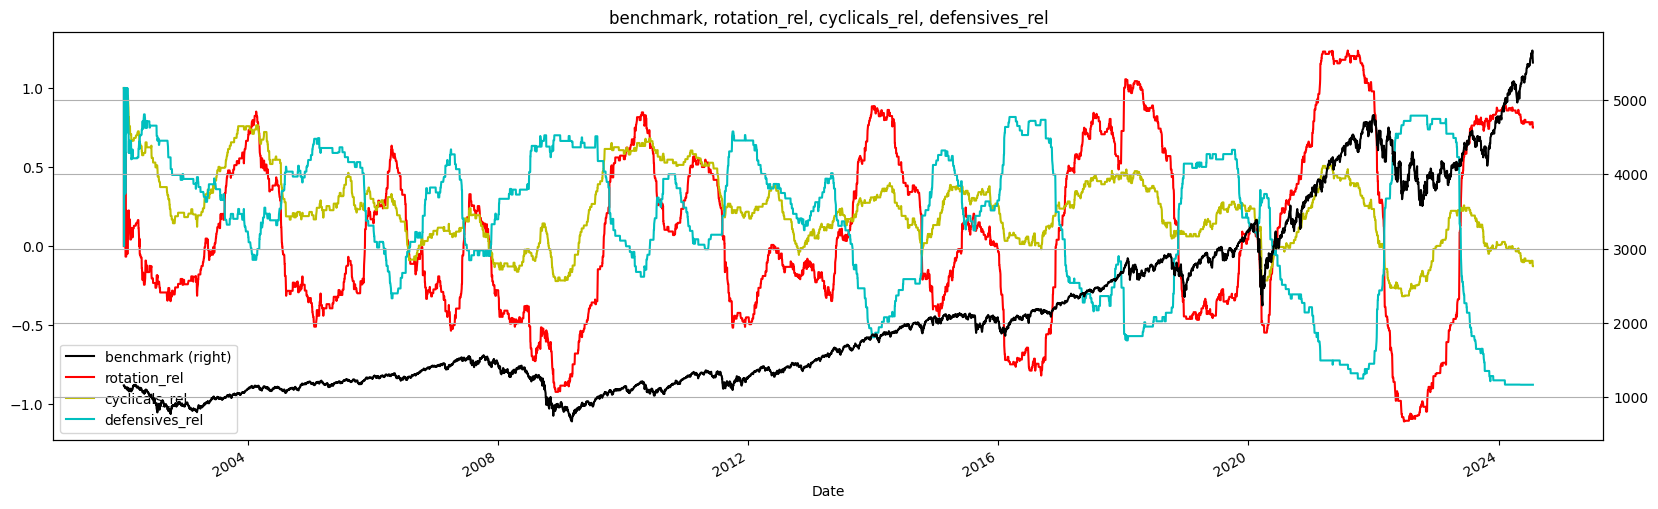

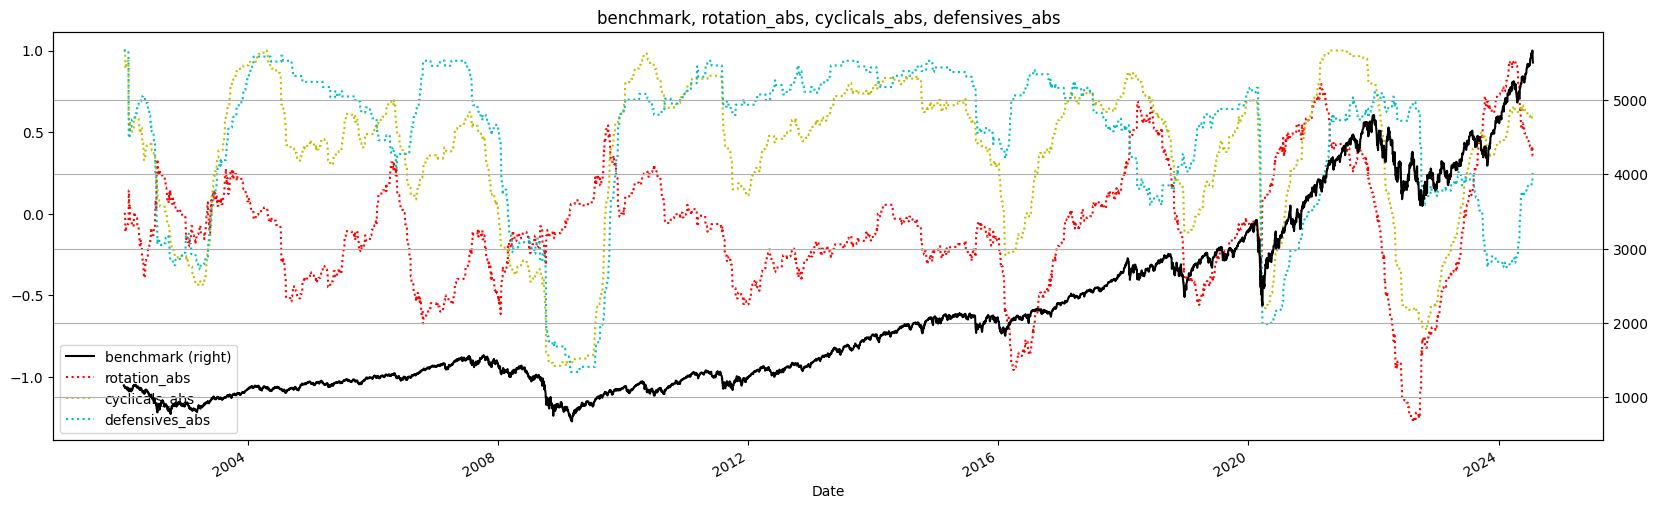

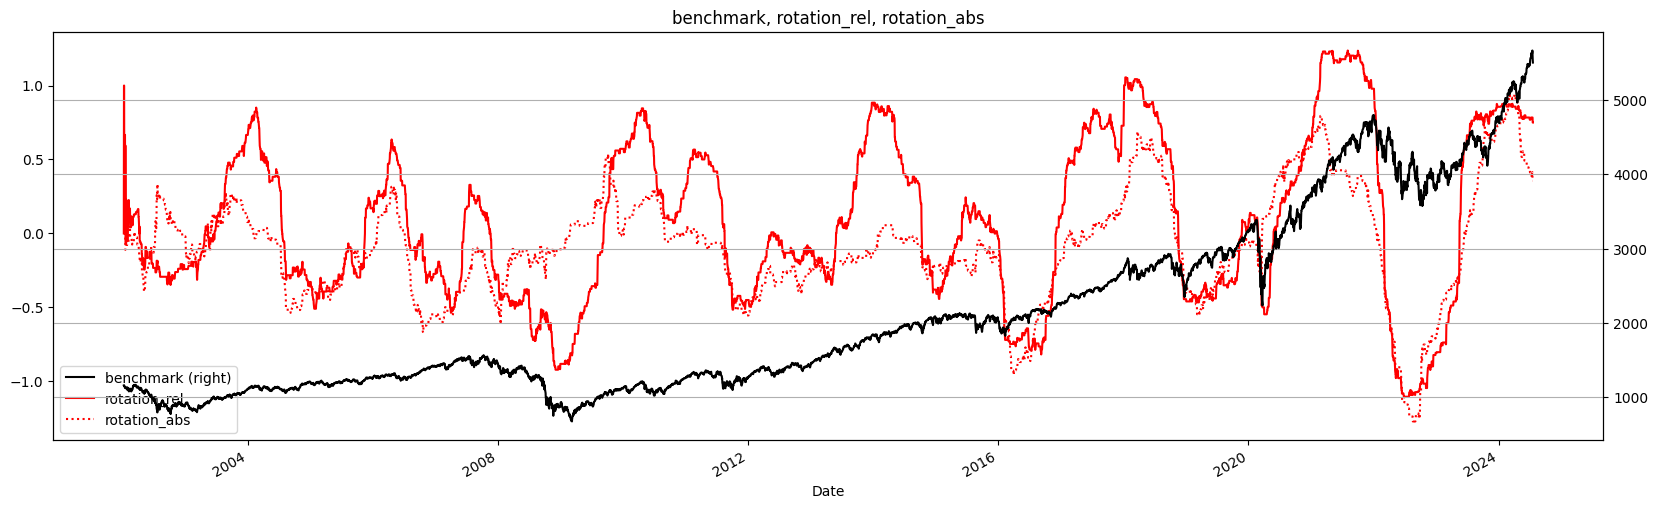

In [21]:
fig9 = bullbear[window:][defensives_plot].plot(figsize=(15,5),grid=True,secondary_y=['benchmark'],
            style = ['k','b','b:','g','g:','co-','c+-'],title = 'Defensive sectors in absolute & relative').get_figure()
fig9.savefig(directory/'Ch04_Defensive sectors in absolute & relative.png')

fig10 = bullbear[window:][cyclicals_plot].plot(figsize=(15,5),grid=True,secondary_y=['benchmark'],
            style = ['k','m','m:','r','r:','yo-','y+-'],title = 'Cyclical sectors in absolute & relative').get_figure()
fig10.savefig(directory/'Ch04_Cyclical sectors in absolute & relative.png')

fig11 = bullbear[window:][['benchmark', 'rotation_rel', 'cyclicals_rel','defensives_rel'
                   ]].plot(figsize=(20,6),grid=True,secondary_y=['benchmark'],
            style = ['k','r','y','c'], title = str('benchmark, rotation_rel, cyclicals_rel, defensives_rel') ).get_figure() 
fig11.savefig(directory/'Ch04_benchmark, rotation_rel, cyclicals_rel, defensives_rel.png')                
                   
fig12 = bullbear[window:][['benchmark', 'rotation_abs', 'cyclicals_abs','defensives_abs'
                   ]].plot(figsize=(20,6),grid=True,secondary_y=['benchmark'],
            style = ['k','r:','y:','c:'],title = str('benchmark, rotation_abs, cyclicals_abs, defensives_abs') ).get_figure()
fig12.savefig(directory/'Ch04_benchmark, rotation_abs, cyclicals_abs, defensives_abs.png')                   
                   
fig13 = bullbear[window:][['benchmark', 'rotation_rel','rotation_abs']].plot(figsize=(20,6),grid=True,secondary_y=['benchmark'],
            style = ['k','r','r:'],title = str('benchmark, rotation_rel, rotation_abs') ).get_figure() 
fig13.savefig(directory/'Ch04_benchmark, rotation_rel, rotation_abs.png')

### 10. Cross-market comparison

The relative method is particulary useful to compare stocks in the same sectors. This is a three step process:
1. Build the currency dictionary, download hsitorical data. 
2. Convert into benchmark currency
3. Calculate returns in benchmark currency for the absolute and relative series

Step1:
1. We build a dictionary fo tickers and their correpsponding currency
2. We generate a tickers list from the dictionary
3. We download historical prices in local currency
4. We add the benchmark prices from the bm_df we built earlier
5. We forward fill missing values for the entire df

In [22]:
fx_dict = {'7203.T': 'USDJPY','VOW3.DE' :'EURUSD', 'RNO.PA':'EURUSD','F':'local' ,'TSLA':'local' ,'GM':'local' ,'005380.KS':'USDKRW' }
tickers = list(fx_dict.keys()) ; bm = 'SP500' ; start = '2021-12-30'
px_df = yf.download(tickers,start, end, interval = "1d",group_by = 'column',auto_adjust = True, prepost = True)['Close']
px_df[bm] = bm_df[start:][[bm]].copy()
px_df = px_df.fillna(method= 'ffill').round(2)
px_df.tail(3)

[*********************100%***********************]  7 of 7 completed


,005380.KS,7203.T,F,GM,RNO.PA,TSLA,VOW3.DE,SP500
Date,,,,,,,,
2024-07-18,260500.0,3141.0,14.55,49.65,49.34,249.23,107.6,5544.59
2024-07-19,258500.0,3133.0,13.98,48.30,48.33,239.20,105.6,5505.00
2024-07-22,257500.0,3104.0,13.98,48.30,48.33,239.20,105.6,5505.00


In [23]:
### Save df and read: NO need to publish in the book version
px_df.to_csv(directory /'px_df.csv')
px_df = pd.read_csv(directory /'px_df.csv', index_col= [0],parse_dates= True).round(2)

1. We calculate daily log returns
2. We calculate cumulative returns using expanding().sum() instead of cumsum() to circumvent NaN
3. We calculate relative cumulative returns in local currency
4. We copy the local price df to instantiate the currency adjusted px_df_usd
5. We loop through the fx_dict to divide the px_df by the corresponding currency

In [24]:
daily_returns_abs = np.log(px_df/px_df.shift())
cumul_returns_abs = daily_returns_abs.expanding().sum().apply(np.exp) - 1
daily_returns_rel = daily_returns_abs.sub(daily_returns_abs[bm], axis=0)
cumul_returns_rel = daily_returns_rel.expanding().sum().apply(np.exp) - 1

px_df_usd = px_df.copy()
for key,value in fx_dict.items():
    px_df_usd[key] = px_df[key].div(ccy_df[value].fillna(method='ffill'))
px_df_usd.head(3)

,005380.KS,7203.T,F,GM,RNO.PA,TSLA,VOW3.DE,SP500
Date,,,,,,,,
2021-12-30,159.239385,17.127484,17.26,56.94,25.307763,356.78,101.706398,4778.73
2021-12-31,158.406985,17.110365,17.51,57.43,25.757111,352.26,102.021823,4766.18
2022-01-03,158.688381,17.098626,18.36,59.91,26.377200,399.93,103.486546,4796.56


In [25]:
### Save df and read: NO need to publish in the book version
px_df_usd.to_csv(directory /'px_df_usd.csv')
px_df_usd = pd.read_csv(directory /'px_df_usd.csv', index_col= [0],parse_dates= True).round(2)

In [26]:
daily_returns_abs_usd = np.log(px_df_usd/px_df_usd.shift())
cumul_returns_abs_usd = daily_returns_abs_usd.expanding().sum().apply(np.exp) - 1
daily_returns_rel_usd = daily_returns_abs_usd.sub(daily_returns_abs_usd[bm], axis=0)
cumul_returns_rel_usd = daily_returns_rel_usd.expanding().sum().apply(np.exp) - 1
cumul_returns_rel_usd.tail(3)

,005380.KS,7203.T,F,GM,RNO.PA,TSLA,VOW3.DE,SP500
Date,,,,,,,,
2024-07-18,0.002607,0.048384,-0.274946,-0.241010,0.562477,-0.409731,-0.152364,0.0
2024-07-19,-0.002688,0.043365,-0.298340,-0.256337,0.546846,-0.429412,-0.159115,0.0
2024-07-22,-0.008567,0.031331,-0.298340,-0.256337,0.547544,-0.429412,-0.158768,0.0


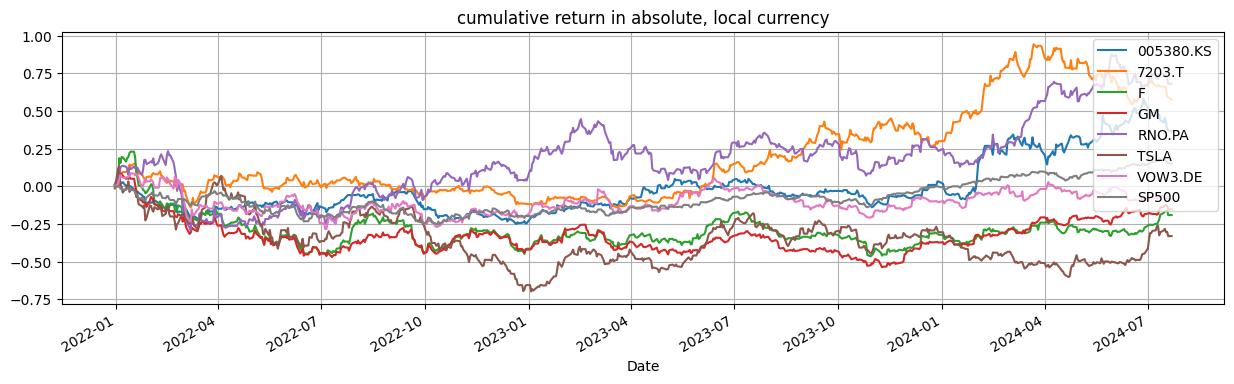

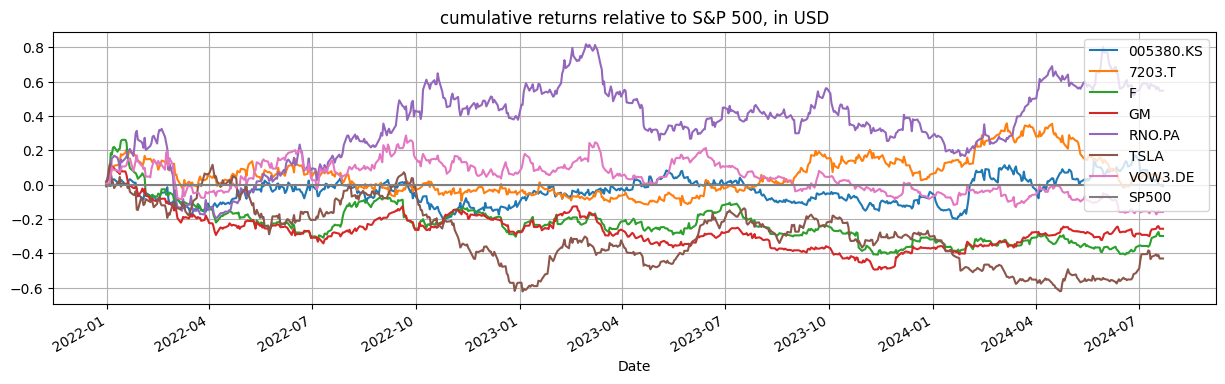

In [27]:
fig14 = cumul_returns_abs.plot(figsize=(15,4), grid= True, title = 'cumulative return in absolute, local currency').get_figure() 
fig14.savefig(directory/'Ch04_cumulative return in absolute, local currency.png')

fig15 = cumul_returns_rel_usd.plot(figsize=(15,4),grid=True,
                                   title = 'cumulative returns relative to S&P 500, in USD').get_figure() 
fig15.savefig(directory/'Ch04_cumulative returns relative to S&P 500, in USD.png')

In [28]:
def returns_table(daily_returns, range_days):
    daily_returns.index = pd.to_datetime(daily_returns.index)
    _day = daily_returns.index.max().day 
    _week = daily_returns.index.max().week
    _month = daily_returns.index.max().month
    _quarter = daily_returns.index.max().quarter
    _year = daily_returns.index.max().year
    dt_today = datetime.date(_year, _month, _day)

    rtrns_df = pd.DataFrame()
    rtrns_df['1D'] = daily_returns.fillna(method='ffill')[-1:].sum()
    rtrns_df["WTD"] = daily_returns[(pd.DatetimeIndex(daily_returns.index).year == _year -1)
                            & (pd.DatetimeIndex(daily_returns.index).isocalendar().week == _week)].sum()
    rtrns_df['1W'] = daily_returns[dt_today + timedelta(days = - 7):].sum()
    rtrns_df["MTD"] = daily_returns[(pd.DatetimeIndex(daily_returns.index).year == _year)
                                & (pd.DatetimeIndex(daily_returns.index).month == _month)].sum()
    rtrns_df['1M'] = daily_returns[dt_today + timedelta(days = - 30):].sum()
    rtrns_df["QTD"] = daily_returns[(pd.DatetimeIndex(daily_returns.index).year == _year)
                                & (pd.DatetimeIndex(daily_returns.index).quarter == _quarter)].sum()
    rtrns_df['3M'] = daily_returns[dt_today + timedelta(days = - 90):].sum()
    rtrns_df['6M'] = daily_returns[dt_today + timedelta(days = - 180):].sum()
    rtrns_df["YTD"] = daily_returns[(pd.DatetimeIndex(daily_returns.index).year == _year)].sum()
    rtrns_df['1Y'] = daily_returns[dt_today +timedelta(days = - 364):].sum()
    rtrns_df['2Y'] = daily_returns[dt_today +timedelta(days = - 728):].sum()
    rtrns_df['Max'] = daily_returns.sum()
    rtrns_df = round((np.exp(rtrns_df)-1)*100,1)
    cumsum = daily_returns[dt_today +timedelta(days = - range_days):].cumsum()
    rng = round((cumsum.tail(1) - cumsum.min()) / (cumsum.max() - cumsum.min()),2)
    rtrns_df = pd.concat([rtrns_df,rng.T],axis=1)
    rtrns_df =rtrns_df.rename(columns={rtrns_df.columns[-1]: f'range {range_days}d'})
    return rtrns_df

def heatmap(df, subset_cols, clrmap = 'RdYlGn', prec =1):    
    try:
        return df.style.background_gradient(subset= subset_cols,cmap= clrmap).format(precision = prec)
    except:
        return df.style.background_gradient(subset= subset_cols,cmap= clrmap).set_precision(prec)

returns_table_abs = returns_table(daily_returns_abs, range_days=364)
returns_table_rel_usd = returns_table(daily_returns_rel_usd, range_days=364)

In [29]:
sort_period = ['6M']
heatmap(returns_table_abs.sort_values(by=sort_period, ascending = False), 
        subset_cols = returns_table_abs.columns, clrmap = 'RdYlGn', prec =1)

,1D,WTD,1W,MTD,1M,QTD,3M,6M,YTD,1Y,2Y,Max,range 364d
005380.KS,-0.4,-1.6,-5.2,-12.7,-8.0,-12.7,5.1,45.6,32.2,35.6,48.7,36.6,0.8
RNO.PA,0.0,3.1,-3.7,1.0,-0.7,1.0,5.8,43.4,36.1,27.7,95.9,68.1,0.8
GM,0.0,-1.3,-1.4,4.0,1.2,4.0,12.1,37.9,35.2,26.7,42.2,-15.2,0.9
F,0.0,-3.8,-0.4,11.5,18.1,11.5,9.8,27.8,19.2,7.1,27.8,-19.0,0.9
TSLA,0.0,2.5,-3.6,20.9,30.7,20.9,68.4,14.4,-3.7,-8.0,-12.1,-33.0,0.8
SP500,0.0,1.0,-2.0,0.8,0.7,0.8,9.9,13.2,15.4,21.4,39.0,15.2,0.9
7203.T,-0.9,1.0,-5.2,-5.7,1.0,-5.7,-11.7,5.0,21.2,38.8,48.9,57.7,0.6
VOW3.DE,0.0,-2.9,-2.7,0.2,0.9,0.2,-5.9,0.3,2.1,-8.6,14.5,-8.6,0.5


In [30]:
heatmap(returns_table_rel_usd.sort_values(by=sort_period, ascending = False), 
        subset_cols = returns_table_rel_usd.columns, clrmap = 'RdYlGn', prec =1)

,1D,WTD,1W,MTD,1M,QTD,3M,6M,YTD,1Y,2Y,Max,range 364d
RNO.PA,0.0,3.5,-2.0,0.2,-1.5,0.2,-4.2,28.7,21.8,9.4,34.5,54.8,0.7
GM,0.0,-2.3,0.5,4.1,1.5,4.1,3.0,23.1,18.3,5.4,3.4,-25.6,0.9
005380.KS,-0.6,-3.0,-4.4,-15.2,-10.3,-15.2,-7.2,21.7,3.4,0.9,-1.2,-0.9,0.6
F,0.0,-4.7,1.6,10.4,17.0,10.4,-0.2,12.7,3.1,-11.9,-8.2,-29.8,0.6
SP500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan
TSLA,0.0,1.4,-1.7,17.6,27.2,17.6,50.3,-0.9,-18.2,-25.7,-38.0,-42.9,0.5
7203.T,-1.2,0.7,-2.9,-1.4,4.5,-1.4,-18.5,-9.9,-2.6,4.9,-3.7,3.1,0.1
VOW3.DE,0.0,-2.5,-1.0,-0.7,0.1,-0.7,-14.8,-10.0,-8.6,-21.7,-21.4,-15.9,0.1


In [31]:
### Save df and read: NO need to publish in the book version
returns_table_abs.to_csv(directory /'returns_table_abs.csv')
returns_table_rel_usd.to_csv(directory /'returns_table_rel_usd.csv')

### 11. Disney MCU rise and fall



In [32]:
ticker = 'DIS' ; bm = 'SP500'; ccy = 'local' ;
df = yf.download(ticker,start = '2017-12-30', end = None ,interval = "1d",group_by = 'column',auto_adjust = True)
start = '2019-12-30'; end= None
df1 = rel_fx(df,_o,_h,_l,_c, bm_df, bm, ccy_df, ccy, start, end,rebase = True, mult = 1)
df2 = rel_fx(df,_o,_h,_l,_c, bm_df, bm, ccy_df, ccy, start, end,rebase = False, mult = 2000)

[*********************100%***********************]  1 of 1 completed


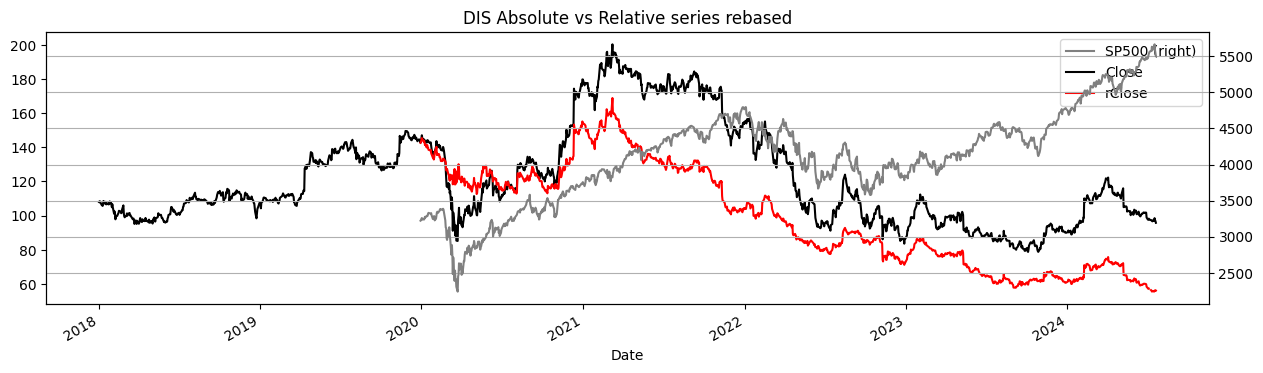

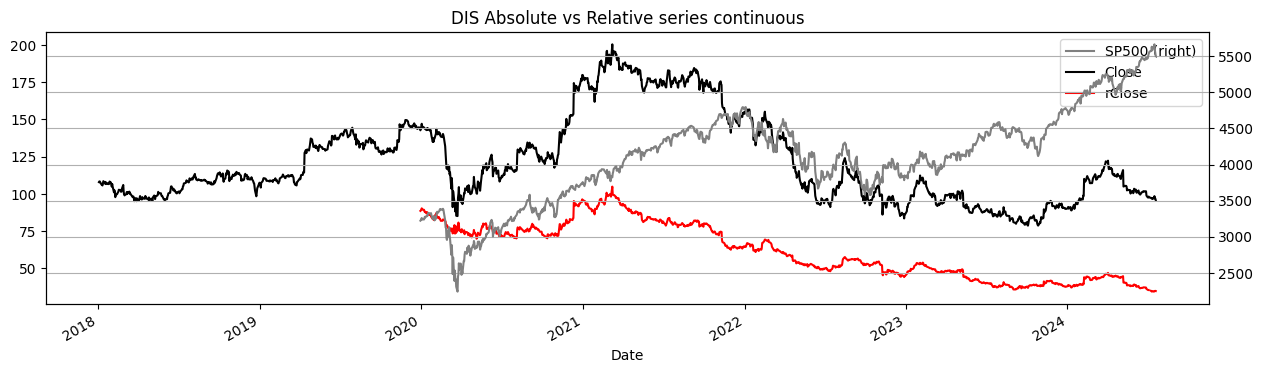

In [33]:
df1 = rel_fx(df,_o,_h,_l,_c, bm_df, bm, ccy_df, ccy, start, end,rebase = True, mult = 1)
fig16 = df1[[bm,'Close','rClose']].plot(figsize=(15,4),grid=True, secondary_y = [bm], 
                                style = ['grey','k', 'r' ],title= f'{ticker} Absolute vs Relative series rebased').get_figure()
fig16.savefig(directory/ f'Ch04_{ticker} Absolute vs Relative series rebased')

df2 = rel_fx(df,_o,_h,_l,_c, bm_df, bm, ccy_df, ccy, start, end,rebase = False, mult = 2000)
fig17 = df2[[bm,'Close','rClose']].plot(figsize=(15,4),grid=True, secondary_y = [bm], 
                                style = ['grey','k', 'r' ],title= f'{ticker} Absolute vs Relative series continuous').get_figure()
fig17.savefig(directory/ f'Ch04_{ticker} Absolute vs Relative series continuous')